# ETFs: Feasibility Analysis

Before building a trading strategy it is worth asking whether the data can support one at all.
This notebook does that and nothing else: it fits no model and makes no forecast.

The strategy being checked is described in `config/setup.yaml`. It trades exchange-traded funds,
ranks them once a month, and holds the ones that rank highest. That file says which funds it
trades, which of them count as liquid enough to hold, how often it changes positions, what it
assumes a trade costs, and how the history is divided between fitting a model and testing it.
This notebook checks each of those assumptions against the data and reports what it finds.

## Learning objectives

By the end of this notebook you will be able to:

- Decide which funds a strategy was allowed to hold on a given date using only information that
  existed before that date, and count how many that leaves on each date it changes positions
- Turn a commission quoted in cents per share into a cost that can be compared across funds
  trading at very different prices
- Read off one chart what fraction of price moves are larger than the cost of trading them
- Measure how much of one month's return carries into the next month, computing the correlation
  inside each fund rather than across a hundred funds stacked into one series
- Check that a walk-forward split of the history fits the sample available and leaves the test
  period unread

## Book reference

Chapter 6, Sections 6.2-6.6. This notebook reads daily fund prices and `config/setup.yaml`, and
writes the eligibility table that the next two notebooks filter on.

## Prerequisites

None beyond what the sections below define. A reader who has not traded funds or split a sample
for walk-forward evaluation will find both explained where they are first used.

In [7]:
"""ETF Case Study - Feasibility Analysis."""

import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import yaml
from IPython.display import display

from case_studies.utils.feasibility import exceedance_curve, fold_timeline, panel_acf
from data import load_etfs, load_etfs_unadjusted
from utils.cv_splits import generate_cv_splits
from utils.paths import get_case_study_dir
from utils.style import COLORS, FIGSIZE, add_message_title, show_with_alt

warnings.filterwarnings("ignore")

In [8]:
CASE_STUDY_ID = "etfs"
START_DATE = "2006-01-01"
END_DATE = "2025-12-31"
ADV_THRESHOLD = 10e6
MIN_SESSIONS_PER_YEAR = 200

## Configuration

Everything the strategy assumes is declared in `config/setup.yaml`, and this notebook reads those
values rather than repeating them, so the two can never disagree. Four groups of settings matter
here, and each one decides something the sections below test.

**How the history is divided.** The sample runs from 2006 to the end of 2025. The last two years
are the *holdout*: a stretch of history that is not looked at while the strategy is being
designed, so that when it is finally evaluated there, the result is not a rehearsal of choices
already tuned on the same data. Everything computed in this notebook uses the earlier part,
called the development period. `holdout_start` is where the line falls.

**What the strategy trades.** `setup.yaml` names 100 funds. Not all of them are tradable at all
times: a fund is admitted to a year only if it traded enough in the year before, which Section
B.2 explains and applies. The strategy holds the leaders only, up to 20 of them, so at least 20
funds have to be admitted on any date it rebalances. That floor comes from the grid of portfolio
sizes the strategy will later search over, not from a separate assumption.

**What a trade is assumed to cost.** Two charges, both quoted in dollars per share: a broker
commission, and half the gap between the price a buyer will pay and the price a seller will
accept. Section B.3 turns them into a cost that is comparable across funds.

**What is being predicted.** The strategy forecasts returns 21 sessions ahead, roughly one month,
and a second variant looks 5 sessions ahead. The 21-session horizon is the primary one, and it
sets both the rebalancing frequency and the gap that has to separate training from validation
data.

One value the strategy depends on is not machine-readable in `setup.yaml`: the dollar-volume
floor a fund has to clear appears only inside `universe.eligibility_note`, as prose. It is
therefore set in the parameters cell above, and Section B.2 says what it does.

In [9]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
SETUP = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())

HOLDOUT_START = str(SETUP["evaluation"]["holdout_start"])
HOLDOUT_END = str(SETUP["evaluation"]["holdout_end"])
PRIMARY_LABEL = SETUP["labels"]["primary"]
LABEL_BUFFER = SETUP["labels"]["buffer"]
DECLARED_ASSETS = set(SETUP["universe"]["assets"])
BREADTH_FLOOR = max(SETUP["backtest"]["sweep"]["top_k_grid"][PRIMARY_LABEL])
PER_SHARE = SETUP["costs"]["per_share"]
HALF_SPREADS = SETUP["costs"]["asset_spreads"]
DEFAULT_HALF_SPREAD = SETUP["costs"]["default_half_spread_usd"]
LABELS = [PRIMARY_LABEL, *SETUP["labels"]["variants"]]
HORIZONS = sorted(int(re.search(r"(\d+)d$", n).group(1)) for n in LABELS)
PRIMARY_HORIZON = int(re.search(r"(\d+)d$", PRIMARY_LABEL).group(1))

print(f"Sample: {START_DATE} to {END_DATE}")
print(f"  Development period, used everywhere below:  {START_DATE} to {HOLDOUT_START}")
print(f"  Holdout, not read by this notebook:         {HOLDOUT_START} to {HOLDOUT_END}")
print(f"Universe: {len(DECLARED_ASSETS)} funds declared")
print(
    f"  Up to {BREADTH_FLOOR} held at once, so at least {BREADTH_FLOOR} must be admitted on a "
    f"rebalancing date to fill the book"
)
print(
    f"  Admitted to a year after averaging ${ADV_THRESHOLD / 1e6:.0f}M of daily turnover in the "
    f"year before"
)
print(
    f"Assumed cost: ${PER_SHARE} per share in commission, plus a half-spread of "
    f"${min(HALF_SPREADS.values())} to ${DEFAULT_HALF_SPREAD} per share by liquidity tier"
)
print(
    f"Forecast horizons: {' and '.join(f'{h} sessions' for h in HORIZONS)} ahead; "
    f"{PRIMARY_HORIZON} sessions is the primary horizon and sets the rebalancing frequency"
)

Sample: 2006-01-01 to 2025-12-31
  Development period, used everywhere below:  2006-01-01 to 2024-01-01
  Holdout, not read by this notebook:         2024-01-01 to 2025-12-31
Universe: 100 funds declared
  Up to 20 held at once, so at least 20 must be admitted on a rebalancing date to fill the book
  Admitted to a year after averaging $10M of daily turnover in the year before
Assumed cost: $0.0035 per share in commission, plus a half-spread of $0.005 to $0.02 per share by liquidity tier
Forecast horizons: 5 sessions and 21 sessions ahead; 21 sessions is the primary horizon and sets the rebalancing frequency


## A. Orientation

### What an exchange-traded fund is

An exchange-traded fund holds a portfolio - the shares in an index, a basket of bonds, a stock of
gold in a vault - and issues shares in itself that trade on an exchange like any other stock. A
buyer of one share owns a slice of whatever the fund holds, and can buy or sell it during the
trading day at whatever price the exchange is quoting, rather than subscribing or redeeming with
the fund manager. That is what makes a portfolio like this one practical: exposure to Japanese
equities, to investment-grade credit and to gold are the same kind of instrument, bought the same
way, in the same account, with the same order type.

The hundred funds this strategy trades cover most of what an investor can hold that way: broad
equity indices, the sectors within them, individual countries, government and corporate bonds,
currencies, commodities, and rules-based selections such as high-dividend or low-volatility
baskets.

### Why ranking funds is a strategy at all

The strategy does not take a view on any one market. Once a month it sorts the funds it is
allowed to hold by some measure of their recent behaviour, buys the ones at the top, and sells
whatever has dropped out. What it is betting on is that the ordering carries: that a fund near the
top this month is more likely than not to be above average next month. Whether that is true is a
question for Chapter 7 onwards. What this notebook asks is whether the data could support the
attempt.

A strategy of that shape needs breadth more than it needs depth. Choosing 20 funds out of 5 is not
a choice, so it matters more that many funds are quoting at once than that any one of them is
quoting well.

### The three questions this notebook asks

1. **Does the universe exist when the strategy trades?** Positions change once a month, so enough
   funds have to be tradable on each of those dates to fill the book.
2. **Is a typical price move worth more than it costs to capture?** Every round trip pays a
   commission and crosses the gap between the buying and the selling price, twice, and those
   charges are a different fraction of the price for a $20 fund than for a $500 one.
3. **Is there enough history to evaluate this honestly?** Enough to split into training and
   validation periods several times over, with the holdout left untouched.

## B. Universe and cost feasibility

### B.1 Load the data and look at the universe

The loader returns one row per fund and session. Its `close` is *adjusted*: when a fund splits its
shares or pays a distribution, the whole earlier history is rescaled so that the change does not
appear as a price move. Differences of an adjusted series are therefore returns rather than
corporate-action artefacts, which is why it is the series used for measuring moves.

A dollar amount cannot use it. The rescaling divides out of a ratio and does not divide out of a
price, so an early adjusted close is not the price anyone paid. A second series is therefore
loaded alongside, carrying the traded price and the shares that traded. **Returns come from the
adjusted series and dollars from the traded one**, and every quantity below says which it used.

The two agree at the end of the sample and diverge going back, for two separate reasons that the
first session below shows together. Every distribution a fund has paid since lowers its adjusted
price, which is why the adjusted close is the lower of the two for most funds. Every split
rescales it as well, and that one runs either way: a fund that later split four for one has an
adjusted 2006 close near a quarter of what it traded at, and a fund that later did a reverse
split has one several times above it.

Three properties are checked before anything is computed: nothing outside the declared list of
funds, no close at or below zero, since every ratio below divides by one, and a traded price for
every adjusted one, since a missing one would silently drop a fund from the screen.

In [ ]:
traded = load_etfs_unadjusted(start_date=START_DATE, end_date=END_DATE).select(
    [
        "symbol",
        "timestamp",
        pl.col("close").alias("traded_close"),
        pl.col("volume").alias("traded_volume"),
    ]
)
prices = (
    load_etfs(start_date=START_DATE, end_date=END_DATE)
    .select(["symbol", "timestamp", "close", "volume"])
    .join(traded, ["symbol", "timestamp"], how="left")
    .sort(["symbol", "timestamp"])
)
research = prices.filter(pl.col("timestamp") < pl.lit(HOLDOUT_START).str.to_date())

undeclared = sorted(set(prices["symbol"].unique().to_list()) - DECLARED_ASSETS)
assert (
    not undeclared
), f"loaded but absent from setup.yaml::universe.assets: {undeclared}"
assert prices["close"].min() > 0, "a non-positive close is not a denominator"
untraded = prices.filter(pl.col("traded_close").is_null())
assert untraded.is_empty(), (
    f"{len(untraded):,} adjusted closes have no traded price, so any dollar screen would "
    f"silently skip them: {sorted(untraded['symbol'].unique().to_list())[:5]}"
)
print(
    f"{research['symbol'].n_unique()} funds, {len(research):,} daily closes, "
    f"{research['timestamp'].min()} to {research['timestamp'].max()}"
)

_first = research.filter(pl.col("timestamp") == pl.col("timestamp").min())
_gaps = _first.with_columns(
    traded_over_adjusted=pl.col("traded_close") / pl.col("close")
).sort("traded_over_adjusted", descending=True)
print(
    f"On the first session, {_first['timestamp'][0]}, {len(_gaps)} funds were quoting. The traded "
    f"close is above the adjusted one for "
    f"{(_gaps['traded_over_adjusted'] > 1).sum()} of them, median "
    f"{_gaps['traded_over_adjusted'].median():.2f}x, and the two extremes are the funds that later "
    f"split:"
)
display(
    pl.concat([_gaps.head(2), _gaps.tail(2)]).select(
        "symbol",
        adjusted=pl.col("close").round(2),
        traded=pl.col("traded_close").round(2),
        traded_over_adjusted=pl.col("traded_over_adjusted").round(2),
    )
)

100 funds, 420,462 daily closes, 2006-01-03 to 2023-12-29
On the first session, 2006-01-03, 59 funds were quoting. The traded close is above the adjusted one for 55 of them, median 1.91x, and the two extremes are the funds that later split:


symbol,adjusted,traded,traded_over_adjusted
str,f64,f64,f64
"""VUG""",7.33,54.28,7.41
"""RSP""",30.39,168.78,5.55
"""EWJ""",39.57,13.95,0.35
"""OIH""",617.01,135.86,0.22


A hundred tickers is a list, not a description. The way the cost model already groups them is by
how much they trade, because that is what decides how wide the gap between the buying and the
selling price is likely to be. `setup.yaml::costs.asset_spreads` names two tiers and leaves the
rest to a default:

- **Half a cent** for the seven funds tracking the largest indices: the S&P 500, the Nasdaq 100,
  the Dow, the Russell 2000, the total US market, developed markets outside the US, and emerging
  markets.
- **One cent** for the eleven funds holding the sectors of the S&P 500, one each.
- **Two cents** for the remaining funds: countries, bonds, currencies, commodities, industries and
  rules-based selections.

That assignment comes from industry knowledge rather than from the data, because daily bars carry
no bid and no ask. The table below is the check on it. *Turnover* is the number of shares that
changed hands multiplied by the price, so it measures money traded rather than shares traded, and
it is the quantity Section B.2's eligibility rule reads. If the tiers are sensible, turnover should
fall as the assumed spread widens, and it does, by roughly a factor of five at each step.

In [ ]:
half_spread = pl.col("symbol").replace_strict(
    HALF_SPREADS, default=DEFAULT_HALF_SPREAD, return_dtype=pl.Float64
)
arrivals = research.group_by("symbol").agg(pl.col("timestamp").min().alias("arrived"))
tiers = (
    research.with_columns(
        half_spread_usd=half_spread,
        turnover=pl.col("traded_close") * pl.col("traded_volume"),
    )
    .join(arrivals, "symbol")
    .group_by("half_spread_usd")
    .agg(
        pl.col("symbol").n_unique().alias("funds"),
        pl.col("close").median().round(2).alias("median_close_usd"),
        (pl.col("turnover").median() / 1e6)
        .round()
        .cast(pl.Int64)
        .alias("median_turnover_musd"),
        pl.col("arrived").max().alias("last_arrival"),
    )
    .sort("half_spread_usd")
)
with pl.Config(tbl_rows=tiers.height, tbl_cols=tiers.width):
    display(tiers)

half_spread_usd,funds,median_close_usd,median_turnover_musd,last_arrival
f64,u32,f64,i64,date
0.005,7,77.1,2168,2006-01-03
0.01,11,24.21,480,2018-06-19
0.02,82,39.75,80,2013-07-18


### B.2 How many funds the strategy is allowed to hold when it rebalances

Not every fund can be held on every date. A fund that barely traded in 2009 could not have been
bought in size in 2009, whatever it does today, so the strategy admits a fund to a year only if it
averaged more than the declared floor in daily turnover over the *previous* year. Deciding
membership from the year before is what makes the rule usable in real time: on the first trading
day of any year, everything it reads has already happened.

The alternative is the mistake this guards against. Selecting funds on turnover measured over the
whole sample would admit exactly the funds that turned out to stay liquid, and the strategy would
be tested on a universe assembled with knowledge it could not have had. A rule read on prior
information only is called *point-in-time*, and it is the difference between a backtest and a
rehearsal.

Two details of the rule are worth stating. A fund quoting for only part of a year has no full year
of turnover to be admitted on, so a minimum number of trading days is required before the average
means anything. And the turnover is the traded price times the shares that changed hands, not the
adjusted price: a distribution rescales the earlier history of an adjusted series, so reading a
dollar floor off it would apply the rule to a number no one ever traded at, and apply it hardest
in the earliest years where the accumulated distributions are largest.

In [ ]:
eligibility = (
    prices.with_columns(
        turnover=pl.col("traded_close") * pl.col("traded_volume"),
        year=pl.col("timestamp").dt.year(),
    )
    .group_by(["symbol", "year"])
    .agg(pl.col("turnover").mean().alias("avg_turnover"), pl.len().alias("n_days"))
    .filter(
        (pl.col("n_days") >= MIN_SESSIONS_PER_YEAR)
        & (pl.col("avg_turnover") >= ADV_THRESHOLD)
    )
    .select("symbol", (pl.col("year") + 1).alias("eligible_year"))
    .unique()
    .sort(["symbol", "eligible_year"])
)

A single count over the whole sample would hide the question a strategy of this shape has to
answer, which is whether enough funds are admitted *at the moment it has to choose between them*.
The strategy rebalances at the last session of each month, so that is where the count is taken,
and it is compared against the 20 positions the largest book has to fill.

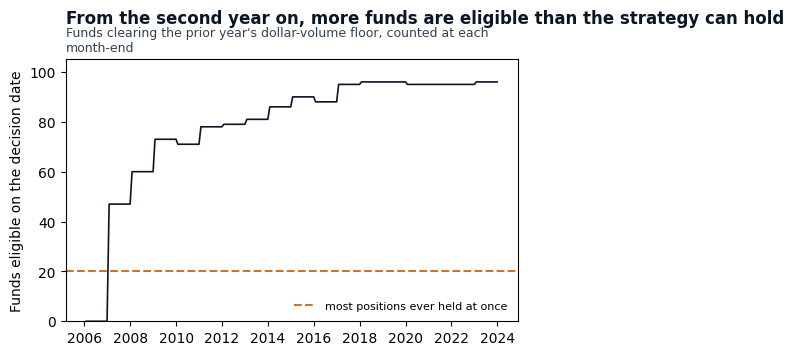

In [ ]:
month_end = research.filter(
    pl.col("timestamp")
    == pl.col("timestamp").max().over(pl.col("timestamp").dt.truncate("1mo"))
)
eligible = eligibility.rename({"eligible_year": "year"}).with_columns(
    eligible=pl.lit(True)
)
breadth = (
    month_end.with_columns(year=pl.col("timestamp").dt.year())
    # a left join keeps the dates on which nothing is eligible, which an inner join drops
    .join(eligible, ["symbol", "year"], how="left")
    .group_by("timestamp")
    .agg(pl.col("eligible").fill_null(False).sum().alias("n_eligible"))
    .sort("timestamp")
)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.plot(
    breadth["timestamp"], breadth["n_eligible"], color=COLORS["blue"], linewidth=1.2
)
ax.axhline(
    BREADTH_FLOOR,
    color=COLORS["copper"],
    ls="--",
    lw=1.5,
    label="most positions ever held at once",
)
ax.set_ylim(0, len(DECLARED_ASSETS) + 5)
ax.set_ylabel("Funds eligible on the decision date")
ax.legend(frameon=False, fontsize=8, loc="lower right")
add_message_title(
    ax,
    "From the second year on, more funds are eligible than the strategy can hold",
    subtitle="Funds clearing the prior year's dollar-volume floor, counted at each month-end",
)
show_with_alt(
    fig,
    "A step line rising from zero at the start of 2006 to about 96 funds by 2018 and flat "
    "afterwards, against a dashed horizontal line at 20 marking the largest book the strategy "
    "ever holds. The line crosses 20 during 2007 and stays well above it for the rest of the "
    "sample.",
)

### B.3 What a round trip costs, and what a move is worth

Buying and later selling the same fund pays two charges, and pays each of them twice.

The first is the broker's **commission**, quoted in cents per share. The second is the **spread**:
at any moment there is a price at which someone will sell and a slightly higher price at which
someone will buy, and a trade that has to happen now crosses that gap. By convention the cost is
charged as half the gap on each side of the round trip, which is why `setup.yaml` states it as a
*half-spread*. Both charges are dollars per share, and neither has anything to do with how
expensive the share is - so the same two cents is a heavier charge on a fund trading at $20 than
on one trading at $500.

That is why the cost has to be converted before it can be compared to a return. Expressed as a
fraction of the price, it becomes a number that means the same thing for every fund. The unit
below is the **basis point**, one hundredth of one percent, which is the conventional unit for
quantities this small.

One caveat on the spread. Daily bars record what traded, not what was quoted, so there is no bid
and no ask in this data and the half-spread cannot be measured from it. It is assigned by tier, as
B.1 described, and `17_costs` re-runs the strategy under harsher assumptions to see how much the
answer depends on it.

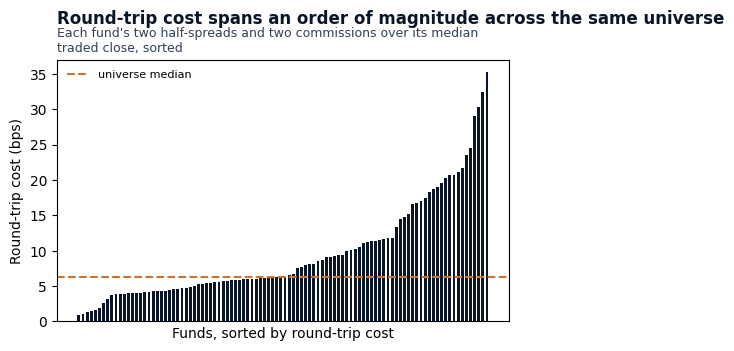

In [ ]:
cost = (
    research.group_by("symbol")
    .agg(pl.col("traded_close").median().alias("price"))
    .with_columns(
        (2 * (half_spread + PER_SHARE) / pl.col("price") * 1e4).alias("cost_bps")
    )
    .sort("cost_bps")
)
COST_BPS = float(cost["cost_bps"].median())

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.bar(cost["symbol"], cost["cost_bps"], color=COLORS["blue"], width=0.7)
ax.axhline(COST_BPS, color=COLORS["copper"], ls="--", lw=1.5, label="universe median")
ax.set_ylabel("Round-trip cost (bps)")
ax.set_xlabel("Funds, sorted by round-trip cost")
ax.set_xticks(
    []
)  # a hundred tickers are unreadable, and the spread of the curve is the point
ax.legend(frameon=False, fontsize=8)
add_message_title(
    ax,
    "Round-trip cost spans an order of magnitude across the same universe",
    subtitle="Each fund's two half-spreads and two commissions over its median traded close, sorted",
)
show_with_alt(
    fig,
    "One bar per fund, sorted left to right, rising from under 1 basis point to about 35. A "
    "dashed line marks the universe median near 6 basis points; most funds sit between 2 and "
    "12, and a short tail at the right runs above 20.",
)

Because those costs differ by an order of magnitude, a single cost line drawn across raw returns
would answer the question for no fund in particular: a move that clears the charge on a
large-index fund need not clear it on a thinly traded one. Each move is therefore divided by what
its own fund would have charged at the price the position opened at. On that scale the break-even
point is 1 for every fund, whatever its own cost happens to be.

The chart below is an **exceedance curve**, and it reads from the right: for each multiple on the
horizontal axis, the curve gives the fraction of moves at least that large. Where it crosses the
line at 1 is the fraction of moves bigger than the cost of trading them.

It is drawn over the fund-years the eligibility rule admits, not over every row of the panel. A
move in a fund the strategy was not allowed to hold that year is not an opportunity it missed, and
counting it would overstate how often a move clears its cost.

One thing this chart is not. It is the distribution of how far prices move, measured over every
admitted fund and every session in the development period, ignoring direction. It is not the
return a strategy would earn: nothing here is signed, nothing waits a day to enter, and nothing is
restricted to the rebalancing dates. Whether the strategy can pick which moves to be on the right
side of is the question Chapter 7 onwards asks. This is only whether the moves are large enough to
be worth trying.

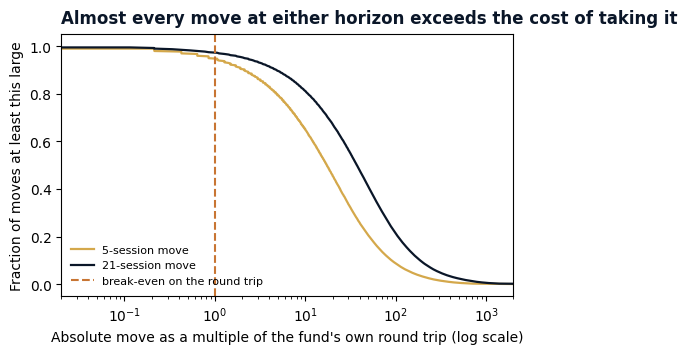

In [15]:
tradable = research.with_columns(year=pl.col("timestamp").dt.year()).join(
    eligibility.rename({"eligible_year": "year"}), ["symbol", "year"], how="semi"
)
returns = tradable.with_columns(
    cost_bps=2 * (half_spread + PER_SHARE) / pl.col("traded_close") * 1e4
).with_columns(
    (pl.col("close").pct_change(h).abs() * 1e4 / pl.col("cost_bps").shift(h))
    .over("symbol")
    .alias(f"h{h}")
    for h in HORIZONS
)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for h, color in zip(HORIZONS, (COLORS["amber"], COLORS["blue"]), strict=True):
    multiple, fraction = exceedance_curve(returns[f"h{h}"].drop_nulls().to_numpy())
    ax.plot(multiple, fraction, color=color, lw=1.6, label=f"{h}-session move")
ax.axvline(
    1, color=COLORS["copper"], ls="--", lw=1.5, label="break-even on the round trip"
)
ax.set_xscale("log")
ax.set_xlim(0.02, 2_000)
ax.set_xlabel("Absolute move as a multiple of the fund's own round trip (log scale)")
ax.set_ylabel("Fraction of moves at least this large")
ax.legend(frameon=False, fontsize=8, loc="lower left")
add_message_title(
    ax, "Almost every move at either horizon exceeds the cost of taking it"
)
show_with_alt(
    fig,
    "Two falling curves on a logarithmic horizontal axis giving the fraction of moves at least "
    "a given multiple of the fund's own round-trip cost. Both start near 1.0 and are still "
    "close to it at the dashed break-even line at one times cost, the 21-session curve sitting "
    "above the 5-session one throughout, and both reach zero beyond a hundred times cost.",
)

### B.4 How much of one month's return carries into the next

A position opened at one month-end and closed at the next earns that fund's return over the
interval. Before building anything that forecasts that return, it is worth asking how much of it
the fund's own recent history already accounts for. If funds that rose last month tend to rise
again, the simplest imaginable ranking - buy last month's leaders - is already a strategy, and the
rebalancing schedule has to be fast enough to act on that tendency before it fades.

The measurement is an **autocorrelation**: the correlation between a fund's return in one month
and its return some number of months later. Plotted against that number of months, it shows how
much of the series its own past accounts for, and how quickly that fades.

It is computed inside each fund and then averaged across funds. Stacking a hundred funds into one
long series and correlating that returns a number too, and the number is wrong: at every point
where one fund's history ends and the next begins, it correlates gold with Brazilian equities. The
shaded region shows how much the result varies from fund to fund, and the band around zero shows
how large a correlation could plausibly be if a fund's returns carried no information about their
own past at all.

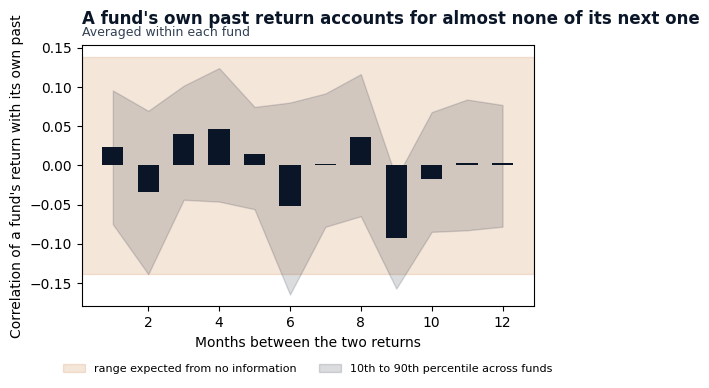

In [ ]:
monthly = month_end.with_columns(
    monthly_return=pl.col("close").pct_change().over("symbol")
)
# a series correlated with itself is 1 by construction, and that bar would flatten every other one
acf = panel_acf(
    monthly, entity_col="symbol", value_col="monthly_return", max_lags=12
).filter(pl.col("lag") > 0)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.axhspan(
    -acf["band"][0],
    acf["band"][0],
    color=COLORS["copper"],
    alpha=0.18,
    zorder=0,
    label="range expected from no information",
)
ax.fill_between(
    acf["lag"],
    acf["acf_p10"],
    acf["acf_p90"],
    color=COLORS["blue"],
    alpha=0.15,
    label="10th to 90th percentile across funds",
)
ax.bar(acf["lag"], acf["acf"], color=COLORS["blue"], width=0.6)
ax.set_xlabel("Months between the two returns")
ax.set_ylabel("Correlation of a fund's return with its own past")
ax.legend(
    frameon=False, fontsize=8, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.18)
)
add_message_title(
    ax,
    "A fund's own past return accounts for almost none of its next one",
    subtitle="Averaged within each fund",
)
show_with_alt(
    fig,
    "Bars for lags of one to twelve months, alternating in sign and all between -0.05 and "
    "+0.05, drawn against a shaded band marking what no information would produce. Every bar "
    "is small enough to sit inside that band, and the 10th-to-90th-percentile spread across "
    "funds is several times wider than the average bar at every lag.",
)

### B.5 Move size against cost

Two numbers summarise what B.3 drew. The first is the median absolute move over one rebalancing
interval divided by the median round trip, which says how much larger a typical move is than a
typical cost. The second is the share of moves larger than what their own fund charges, which is
where the exceedance curve crosses its break-even line.

Neither says the strategy earns anything. Both count a move down exactly as they count a move up,
and nothing here decides which side of it a position would have been on. What they rule out is the
case where the design fails immediately, because a typical move is smaller than the cost of
capturing it.

In [17]:
moves = returns.select(
    move_bps=1e4 * pl.col("close").pct_change(PRIMARY_HORIZON).abs().over("symbol"),
    clears=pl.col(f"h{PRIMARY_HORIZON}") > 1,
)
print(
    f"Round trip {cost['cost_bps'].min():.2f} to {cost['cost_bps'].max():.2f} bps across funds, "
    f"median {COST_BPS:.2f} bps\n"
    f"Median absolute {PRIMARY_HORIZON}-session move {moves['move_bps'].median():.1f} bps, "
    f"{moves['move_bps'].median() / COST_BPS:.0f}x the median round trip\n"
    f"Share of moves larger than their own fund's round trip {moves['clears'].mean():.3f}"
)

Round trip 0.86 to 35.23 bps across funds, median 6.29 bps
Median absolute 21-session move 288.3 bps, 46x the median round trip
Share of moves larger than their own fund's round trip 0.973


The round trip costs between 0.86 and 35.23 bps at each fund's median traded close, a universe
median of 6.29 bps. The median absolute 21-session move is 288.3 bps, forty-six times that, and
0.973 of moves are larger than the round trip charged by the fund on which they occurred.

## C. Design decisions

The sections above are evidence. This section is where that evidence meets the choices recorded in
`setup.yaml`, and says what each one rests on.

### C.1 How often to rebalance

`setup.yaml` ranks the funds at the month-end close and trades at the next open. Section B.3
supports trading that often: moves over one rebalancing interval are far larger than the round
trip their own fund charges, so cost is not what would force a slower schedule. Section B.4
supports it from the other side, by ruling out the reason to trade faster. A fund's own past
return accounts for almost none of its next one, so there is no quickly fading tendency that a
monthly schedule would arrive too late for. Whatever the ranking ends up reading has to come from
somewhere other than the fund's last return, and Chapter 7 onwards builds it.

The interval has one further consequence. The return being predicted is the one 21 sessions
ahead, which is about the number of trading sessions in a month, so each position is held for
roughly the period its own label measures and one holding is largely finished before the next
begins. The 5-session variant stays in `labels.variants` so a shorter holding period is measured
as well.

### C.2 What would send this design back

A feasibility study is only useful if some result would have stopped it. Three would, and each is
measured where its evidence exists rather than here.

The one this notebook could have produced is a cost failure: if a typical move were smaller than
the round trip needed to capture it, the ranking would pay more to trade than the move it is
trying to catch, and no model would repair that. Section B.5 is that measurement, and Chapter 18
repeats it against the trades a backtest actually places rather than against raw moves.

The other two are outcomes of the strategy rather than properties of the data. Chapter 7 asks
whether the ranking has any relationship at all to the returns that follow it, at any lookback
window. Chapter 16 asks whether simply holding every eligible fund in equal weight earns more per
unit of risk, and loses less at its worst, than the ranking does - if it does, the ranking is not
paying for the trading it causes.

### C.3 What the strategy does with the ranking

`setup.yaml` buys the funds at the top of the ranking and takes no position in the ones at the
bottom. Betting against a fund means borrowing its shares in order to sell them, and for many of
these funds those shares are expensive or impossible to borrow, so a short leg would be measuring
the cost of the borrow as much as the quality of the ranking.

Each fund held gets an equal share of the money. A weighting optimised for risk would fold an
estimate of how the funds move together into the result, and the ranking's own contribution could
no longer be separated from that estimate's. Chapter 17 compares the alternatives with the ranking
held fixed.

## D. Walk-forward structure

### D.1 How much an evaluation has to spend

A panel of daily prices looks large, but a strategy that changes its positions once a month does
not get to treat every row as an independent opportunity. What it spends is decision dates. Three
numbers describe the sample from that point of view: how many sessions it contains, how many of
them are dates the strategy acts on, and how many funds it can choose between on a typical one.

In [18]:
print(
    f"Sessions {research['timestamp'].n_unique():,} | decision dates {len(breadth):,} "
    f"| eligible funds per decision date {breadth['n_eligible'].mean():.0f}"
)

Sessions 4,529 | decision dates 216 | eligible funds per decision date 79


### D.2 The folds

A model is fitted on one stretch of history and evaluated on the stretch that follows it, then the
pair moves forward and the process repeats. Each fit-then-evaluate pair is a **fold**, and
evaluating this way is called **walk-forward**, because the split always runs in the direction
time does.

One detail decides whether the evaluation is honest. The return being predicted lands 21 sessions
ahead, so a training row dated near the end of its block is labelled with a price from after the
block ends. Validating on the session immediately after training would score the model on data it
had partly seen already. The fix is to leave a gap between the two, at least as wide as the
horizon, and that gap is called **purging**. Its width comes from `labels.buffer` in `setup.yaml`;
the 5-session variant declares a shorter gap of its own, which the primary label's gap covers.

The three assertions below establish what the figure cannot. The gap is 21 sessions against
training blocks measured in years, too narrow to see, so only counting it off the session timeline
can confirm it is as wide as the horizon. The other two check that the number of folds is the
number `setup.yaml` declares, and that no validation window reaches into the holdout. The figure
then draws the boundaries the splitter returned rather than recomputing them, so the picture and
the folds cannot disagree.

`generate_cv_splits` numbers folds chronologically, so fold 0 is the earliest and the highest
number is the last one before the holdout. The figure draws them earliest-first and labels each
with that number, so the labels count up alongside the dates; every later stage prints the same
ones.

The splitter is given the whole sample, holdout included, and applies the holdout boundary itself
from `evaluation.holdout_start`, which is what every later stage does too. Trimming the data first
would shift the first training date of most folds by a few sessions, and the figure would then
show a training window the pipeline never trains on.

In [ ]:
splits = generate_cv_splits(
    prices.select("timestamp"),
    case_study_id=CASE_STUDY_ID,
    label_buffer=LABEL_BUFFER,
    date_col="timestamp",
)
sessions = prices.select("timestamp").unique().sort("timestamp")["timestamp"].to_numpy()
purge_gaps = {
    int(
        (
            (sessions > np.datetime64(s["train_end"]))
            & (sessions < np.datetime64(s["val_start"]))
        ).sum()
    )
    for s in splits
}
last_val = max(s["val_end"] for s in splits)
assert (
    len(splits) == SETUP["evaluation"]["n_splits"]
), "fold count differs from setup.yaml"
assert last_val < np.datetime64(HOLDOUT_START), "a fold reaches into the holdout"
assert purge_gaps == {PRIMARY_HORIZON}, "a purge gap is not the primary label horizon"

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
fold_timeline(ax, splits, holdout=(HOLDOUT_START, HOLDOUT_END))
purge_note = (
    f"Training, the {PRIMARY_HORIZON}-session purge gap, validation, and the holdout"
)
add_message_title(
    ax,
    "Each fold trains, pauses, then validates, and none reaches the holdout",
    purge_note,
)
show_with_alt(
    fig,
    "Eight horizontal bars, one per fold, each made of a long dark training block, a thin pale "
    "purge gap and a short amber validation block. Each fold sits one year earlier than the "
    "one below it, and the shaded holdout column on the right is reached by none of them.",
)

RuntimeError: generate_cv_splits produced folds that are not ordered oldest first: val_starts ['2022-12-29 00:00:00', '2021-12-29 00:00:00', '2020-12-29 00:00:00', '2019-12-30 00:00:00', '2018-12-28 00:00:00', '2017-12-27 00:00:00', '2016-12-27 00:00:00', '2015-12-28 00:00:00']. Fold 0 is read as the earliest fold everywhere, and stage-04 artifacts carry these ids, so a descending set joins each fold against the wrong end of the sample. Renumber the source rather than reversing it at the call site.

## E. What this notebook hands on

One table: the fund-year pairs that cleared the liquidity rule. `02_labels` and
`03_financial_features` join on it, so a fund contributes rows only in the years it was admitted
to. It covers the holdout years as well as the development period, because the strategy has to
know which funds it was allowed to hold when it is finally evaluated there. That costs nothing in
terms of what the design has seen: membership in a year is decided entirely by the year before it,
and none of the diagnostics above read a holdout year.

In [ ]:
eligibility.write_csv(CASE_DIR / "eligibility.csv")
print(f"Written: eligibility.csv, {len(eligibility):,} fund-year pairs")

Written: eligibility.csv, 1,704 fund-year pairs


## F. What the evidence says about each setting

One row per setting: the evidence behind it, and the condition under which a reader working on
their own data would choose differently.

| Setting | Evidence | Choose differently when |
|---|---|---|
| `universe.eligibility_rule` | B.2, funds admitted on each decision date | fewer funds are admitted than the strategy has positions to fill |
| `decision.cadence` | B.3 move sizes against cost, B.4 how much of a month's return carries | moves stop covering the round trip, or the return being predicted resolves after the next decision date |
| `costs.asset_spreads` | B.3, the cost per fund from the declared commission and half-spread | quoted spreads become available and disagree with the assigned tier |
| `evaluation.n_splits` | D.1 decision dates, D.2 fold boundaries | the folds no longer fit the development period |

The breadth chart raises a question it cannot answer on its own. A count below the number of
positions to fill matters if it happens in the middle of the sample, where the strategy would find
itself unable to fill the book on an ordinary date. It matters much less if it is confined to the
beginning, before any fund has a prior year to be admitted on, since the evaluation can simply
start after it. So the dates below the floor are counted per year, and the first date after which
breadth never falls below it again is read off the series rather than off the chart.

In [ ]:
thin = breadth.filter(pl.col("n_eligible") < BREADTH_FLOOR).sort("timestamp")
by_year = thin.group_by(pl.col("timestamp").dt.year().alias("year")).len().sort("year")
cleared = breadth.filter(pl.col("timestamp") > thin["timestamp"].max())[
    "timestamp"
].min()

print(
    f"universe.n_assets {SETUP['universe']['n_assets']}, eligible per decision date "
    f"{breadth['n_eligible'].min()} to {breadth['n_eligible'].max()}\n"
    f"below the floor of {BREADTH_FLOOR} on {thin.height} of {len(breadth)} decision dates ("
    + ", ".join(
        f"{n} in {y}" for y, n in zip(by_year["year"], by_year["len"], strict=True)
    )
    + f"), and never again from {cleared}\n"
    f"decision.cadence {SETUP['decision']['cadence']} | labels.primary {PRIMARY_LABEL}\n"
    f"evaluation.n_splits {SETUP['evaluation']['n_splits']}, generated {len(splits)}, "
    f"last validation ends {last_val.date()}, holdout untouched\n"
    f"labels.buffer {LABEL_BUFFER}, purge gap {min(purge_gaps)} sessions against the "
    f"{PRIMARY_HORIZON}-session primary horizon"
)

universe.n_assets 100, eligible per decision date 0 to 96
below the floor of 20 on 12 of 216 decision dates (12 in 2006), and never again from 2007-01-31
decision.cadence monthly_month_end | labels.primary fwd_ret_21d
evaluation.n_splits 8, generated 8, last validation ends 2023-11-29, holdout untouched
labels.buffer 21D, purge gap 21 sessions against the 21-session primary horizon


The number of funds eligible on a decision date runs from 0 to 96 of the declared 100. It sits
below the twenty positions the largest book has to fill on 12 of 216 decision dates, all of them
in 2006, the first year of the sample, when no fund yet has a prior year to be admitted on; from
2007-01-31 it never falls below twenty again. Eight folds are generated, the last validation
window ending 2023-11-29, and the gap between each training block and the validation window that
follows it is 21 sessions, exactly the horizon of the primary label.

## Key takeaways

1. **Decide what a strategy was allowed to hold from information that existed before the date the
   decision applies to.** A liquidity filter applied to the whole sample at once admits exactly
   the funds that turned out to stay liquid, and a backtest run on that universe is measuring a
   choice nobody could have made at the time.
2. **Count the universe on the dates the strategy acts, not over the sample.** An average taken
   over every session hides whether the book could have been filled on the dates that decide the
   result.
3. **Turn a per-share cost into a fraction of the price before comparing it to a return**, and
   divide each move by what its own instrument charges. A cent of spread is a heavy cost on a $20
   fund and a negligible one on a $500 one, so a single cost line drawn across raw returns answers
   the question for no fund in particular.
4. **Measure opportunity over the population the strategy was allowed to trade.** A move in a fund
   that failed the liquidity rule that year was never available, and counting it overstates how
   often a move covers its own cost.
5. **Compute a panel autocorrelation inside each entity, then average.** Stacking entities into
   one series measures the joins between them.

### Known limitations

- The hundred funds were chosen knowing which of them still trade today. The point-in-time rule
  removes a bias within that list; it cannot remove the bias in the list itself.
- The traded price is read from Yahoo, which restates it for splits but not for distributions, so
  the splits are multiplied back out when the series is built. A fund's split history is therefore
  part of the input, and a split Yahoo has not recorded would misstate that fund's cost per share.
- The half-spread is assigned by liquidity tier rather than measured, because daily bars carry no
  bid and no ask. The dollar-volume floor is a fixed amount that is not adjusted for inflation.
- Eligibility is decided once a year while positions change once a month, so a fund that becomes
  illiquid in March keeps its place until January.

**Next**: labels at the declared horizons, built on this development period.